# Study · Temperature compensation on the legacy era, station 02

**Question.** The same one asked in `studies/thermal_compensation`: does the fixed
thermal correction applied by Notebook 00 help or hurt a prediction system built on
the inclinometer signal?

$$ I_{\text{comp}}(t) = I(t) - \big(T_{\text{air}}(t) - T_{\text{air}}(t_0)\big)\cdot c \cdot 1000,
   \qquad c = 0.005 $$

**What is different here.** The first study ran on the current instrument era, which
has wall temperature and solar radiation but only 197 valid days in two disconnected
blocks. This one runs on the legacy era, where the only environmental channels are
**air temperature and relative humidity** — and where a *complete calendar year* of
station 02 is available. A full year is what makes an annual seasonal term
identifiable at all, so this is the setting in which a NeuralProphet decomposition
can be taken seriously.

**What is added.** Every series is decomposed with NeuralProphet into trend and
seasonal components, and the regressor gaps are filled with the same models. The
inclinometer is never imputed: filling the target with a model and then scoring a
model against it would measure nothing.

**The physical hypothesis.** Solar radiation heats the exposed face of the wall, the
heat diffuses into a large masonry mass, and the resulting differential expansion
between that face and the restrained, embanked face tilts the structure. A body with
thermal mass cannot respond instantaneously, so the instantaneous form of the
correction is a property of the correction and not of the wall. This era has no
radiometer, which makes air temperature the closest available proxy for the forcing —
and a proxy that is itself a smoothed, delayed version of it. The lag structure is
therefore measured here on levels as well as on differences, and a thermal time
constant is fitted rather than assumed to be zero.

**Sampling.** Every environmental proxy the pipeline aligns against is published
hourly, so the record is aggregated from its native 20-minute rate to one hour
immediately after parsing and every result below is computed on the hourly grid.

**Shared tests.** The acceptance tests, coefficient sweep, lag and inertia analysis
and forecasting experiment are the *same functions* used by the current-era study,
imported from it rather than reimplemented. Any difference in results is therefore a
difference in the data, not in the method.

## Imports and configuration

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, os.path.abspath('.'))       # lc_lib, local to this study
sys.path.insert(0, os.path.abspath('../../..'))   # heritageshm, at the repo root

import lc_lib as lc

warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 30)

### Parameters

| Parameter | Purpose |
|---|---|
| `CANDIDATE_YEARS` | Years scanned for completeness. See the note in Step 1 for why the others are excluded without scanning. |
| `YEAR` | Analysis year. `None` selects the most complete candidate automatically. |
| `DRIVERS` | The only environmental channels the legacy era provides. |
| `IMPUTE_REGRESSORS` | Fill regressor gaps with their NeuralProphet fit. |
| `NP_DECOMP_EPOCHS` | Training epochs for the decomposition models. |

In [2]:
ARCHIVE_DIR = os.path.expanduser(
    '~/Library/CloudStorage/GoogleDrive-eugeniomoreira@iaud.ufc.br/'
    'My Drive/_UNIPG/__Mura-realtime'
)
CACHE_DIR  = '.cache'
OUTPUT_DIR = 'outputs'
STATION    = 'st02'

CANDIDATE_YEARS = [2019, 2020, 2021]
YEAR            = None          # None = pick the most complete candidate

ANALYSIS_FREQ      = '1h'
CONTEXT            = 'notebook'   # 'paper' re-exports figures at column size
DRIVERS            = ['tair', 'rh']
TEMP_COL           = 'tair'
IMPUTE_REGRESSORS  = True
MAX_LAG_HOURS      = 120          # five days
TAUS               = [0, 1, 2, 3, 4, 6, 8, 12, 18, 24, 36, 48, 72, 96, 120, 168]
BAND_HOURS         = 168          # weekly mean removed for the band-limited scan
N_LAGS_MODEL       = 12
HORIZON_LONG       = 24
TRAIN_FRAC         = 0.70
NP_DECOMP_EPOCHS   = 25
RUN_NEURALPROPHET  = True
NP_EPOCHS          = 20
NP_LAGS            = 24

os.makedirs(OUTPUT_DIR, exist_ok=True)
lc.set_context(CONTEXT)     # seaborn theme and canvas scale for every figure
SAMPLING_HOURS = 1.0
MAX_LAG_STEPS  = int(MAX_LAG_HOURS / SAMPLING_HOURS)

## Step 1 · Choose the year

Whole-day file counts are not a sufficient guide, because a day can exist as a file
while station 02's own block is written as zeros throughout it. The scan below
measures what this study actually needs: grid slots in which the inclinometer, air
temperature and humidity are *all* present.

**Why only three candidates.** From `docs/data-quality-report-2026-08-10.md`, the
whole-day record is: 2018 — 159 days (acquisition began in July); 2019 — 365/365;
2020 — 355/366; 2021 — 365/365; 2022 — 153/365; 2023 — 194/365; 2024 — 284/366;
2025 legacy — 51 days before the changeover. A year missing 212, 171 or 82 whole
days cannot beat one missing none, so 2019, 2020 and 2021 are the only candidates
that need measuring.

In [3]:
years = lc.year_completeness(ARCHIVE_DIR, CACHE_DIR, CANDIDATE_YEARS,
                             station=STATION, required=('inc', 'tair', 'rh'))
display(years)
years.to_csv(f'{OUTPUT_DIR}/S2_01_{STATION}_year_completeness.csv')

,slots,complete,complete_%,longest_run_days,inc_%,tair_%,rh_%
year,,,,,,,
2021,8737,8516,97.47,66.6,97.47,97.47,97.47
2019,8737,7505,85.90,34.0,85.90,85.90,85.90
2020,8761,7270,82.98,43.8,82.98,82.98,82.98


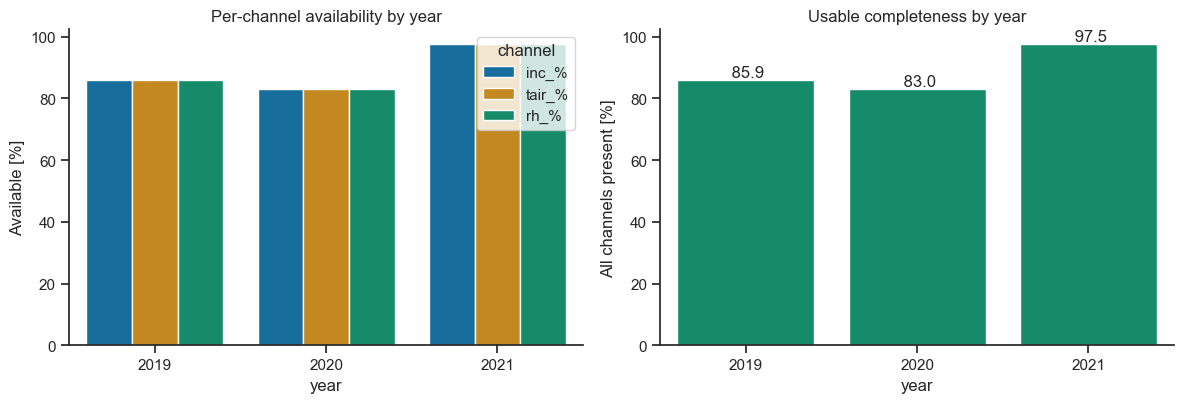

In [4]:
fig = lc.plot_year_completeness(
    years, save_path=OUTPUT_DIR,
    filename=f'S2_02_{STATION}_year_completeness')
plt.show()

In [5]:
if YEAR is None:
    YEAR = int(years.index[0])
print(f'Analysis year: {YEAR}  '
      f'({years.loc[YEAR, "complete_%"]:.1f} % complete, '
      f'longest unbroken run {years.loc[YEAR, "longest_run_days"]:.1f} days)')

Analysis year: 2021  (97.5 % complete, longest unbroken run 66.6 days)


## Step 2 · Load the chosen year

In [6]:
df = lc.load_legacy(ARCHIVE_DIR, CACHE_DIR, f'{YEAR}-01-01', f'{YEAR}-12-31',
                    station=STATION)
df = df.loc[f'{YEAR}-01-01':f'{YEAR}-12-31 23:59']
display(lc.coverage_table(df))
lc.coverage_table(df).to_csv(f'{OUTPUT_DIR}/S2_03_{STATION}_coverage.csv')

  cache: 365 files in range, 0 newly copied, 365 already present


  parsed    : 26067 records from 365 files
  duplicates: 520 records share a timestamp, 64 field-level conflicts merged
  sentinels : 1250 zeros to NaN, 0 inclinometer out of range
  grid      : 26209 slots, 2021-01-01 00:00:00 to 2021-12-31 00:00:00
  resampled : 26209 native slots to 8737 at 1h; 8516 intervals carry the inclinometer, 75 rejected for holding fewer than 2 raw samples


,present,missing,available_%,min,max,mean,std
channel,,,,,,,
batt,8516,221,97.471,3.400,4.690,3.891,0.297
tair,8516,221,97.471,-4.632,38.482,13.710,8.818
rh,8516,221,97.471,19.652,99.938,71.908,22.111
inc,8516,221,97.471,-338.667,-205.417,-272.457,33.891


In [7]:
df, flagged = lc.screen_spikes(df, col='inc', window=3, k=8.0)

  spike screen on "inc": robust sigma of signal 43.30 mdeg, threshold 346.4 mdeg, 0 of 8516 samples removed (0.00 %)


### Gap structure

The shape of the missingness decides what imputation can honestly be asked to do.
Filling a single dropped slot between two good readings is interpolation; filling a
multi-week outage is extrapolation from the seasonal model and nothing more.

In [8]:
gaps = pd.concat({c: lc.gap_profile(df[c]) for c in ['inc'] + DRIVERS},
                 names=['channel']).reset_index(level=0)
display(gaps)
gaps.to_csv(f'{OUTPUT_DIR}/S2_04_{STATION}_gap_profile.csv', index=False)

,channel,band,gaps,slots,hours
0,inc,single slot,44,44,44.0
1,inc,up to 6 h,33,108,108.0
2,inc,6-24 h,7,69,69.0
0,tair,single slot,44,44,44.0
1,tair,up to 6 h,33,108,108.0
2,tair,6-24 h,7,69,69.0
0,rh,single slot,44,44,44.0
1,rh,up to 6 h,33,108,108.0
2,rh,6-24 h,7,69,69.0


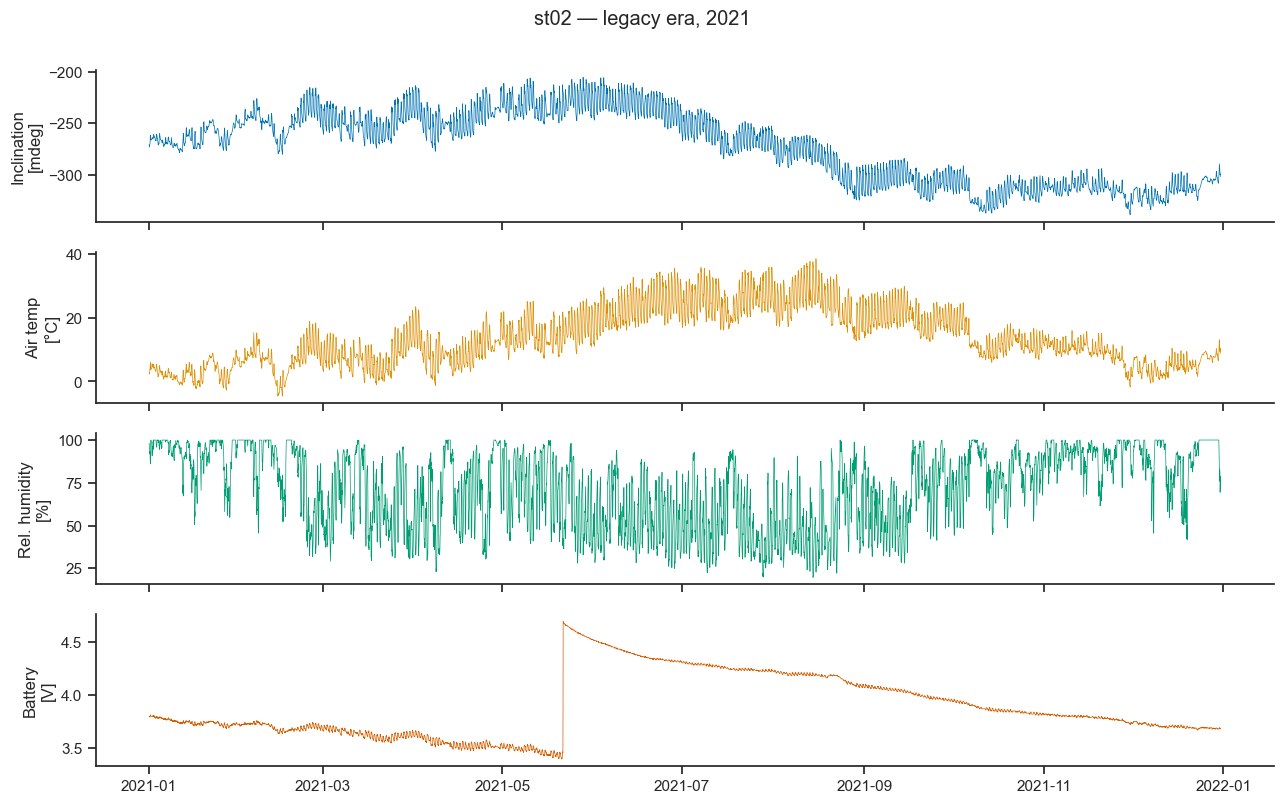

In [9]:
fig = lc.plot_overview(df, cols=('inc', 'tair', 'rh', 'batt'),
                       title=f'{STATION} — legacy era, {YEAR}',
                       save_path=OUTPUT_DIR,
                       filename=f'S2_05_{STATION}_overview')
plt.show()

## Step 3 · NeuralProphet decomposition of every series

Each series is fitted without autoregression, so that every component is a function
of time alone. That is a deliberate restriction: it keeps the components
interpretable, and it is what allows the same fit to be used for imputation, since a
model with autoregressive terms cannot produce a value inside a gap.

A full calendar year gives exactly one pass through the annual cycle. The yearly
term is therefore *estimable but not verifiable* — it cannot be checked against a
second cycle. Read it as a description of this year, not as an established
climatology.

In [10]:
decomp = {}
for name in ['inc'] + DRIVERS:
    print(f'Fitting {name} ...')
    decomp[name], _ = lc.decompose_series(
        df[name], epochs=NP_DECOMP_EPOCHS,
        yearly=True, weekly=True, daily=True)

Fitting inc ...


Importing plotly failed. Interactive plots will not work.


Importing plotly failed. Interactive plots will not work.


Fitting tair ...


Fitting rh ...


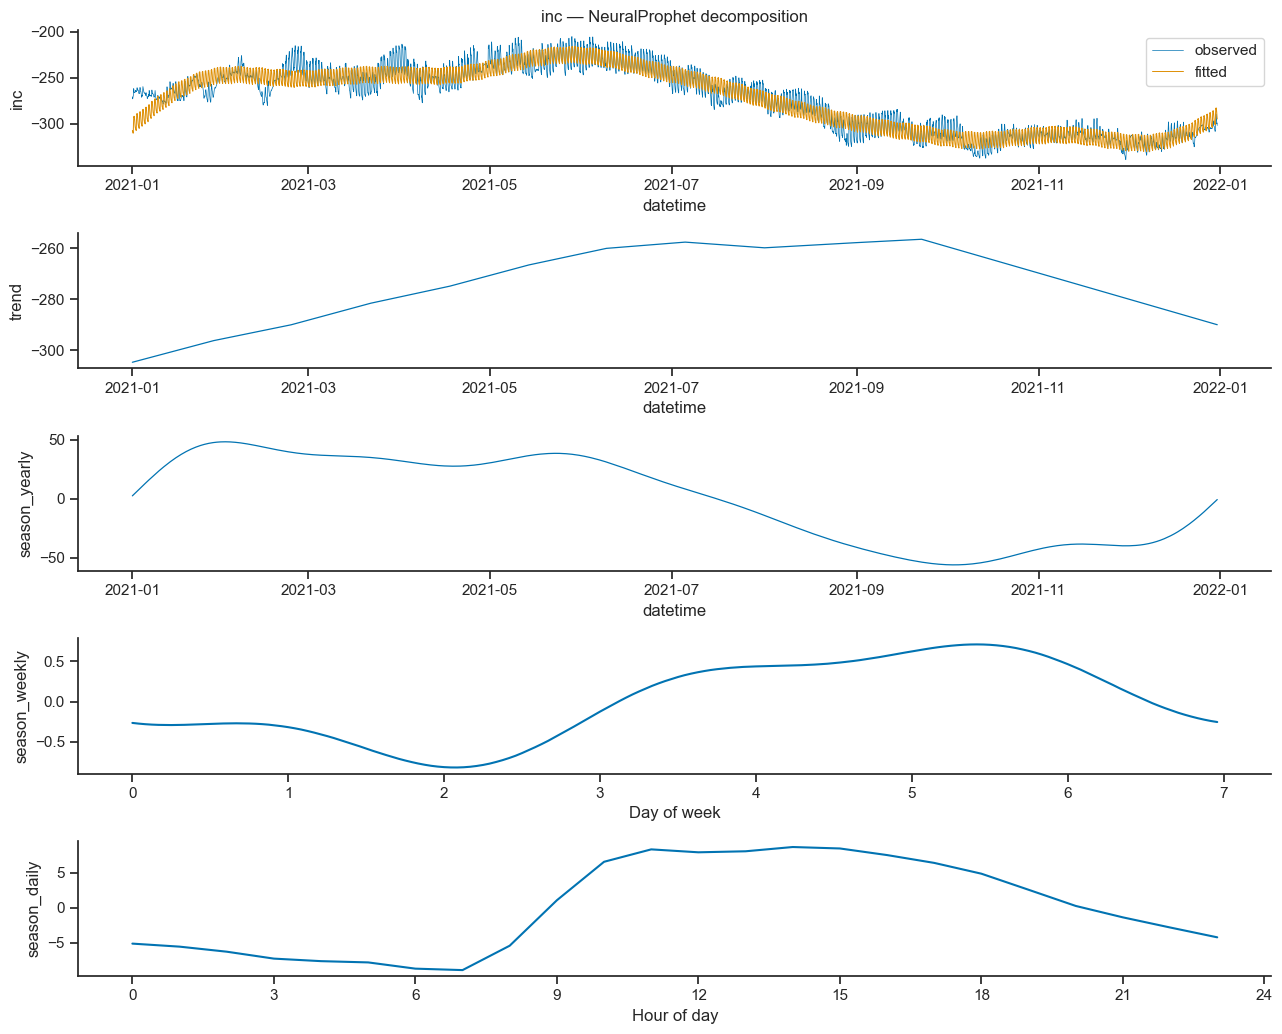

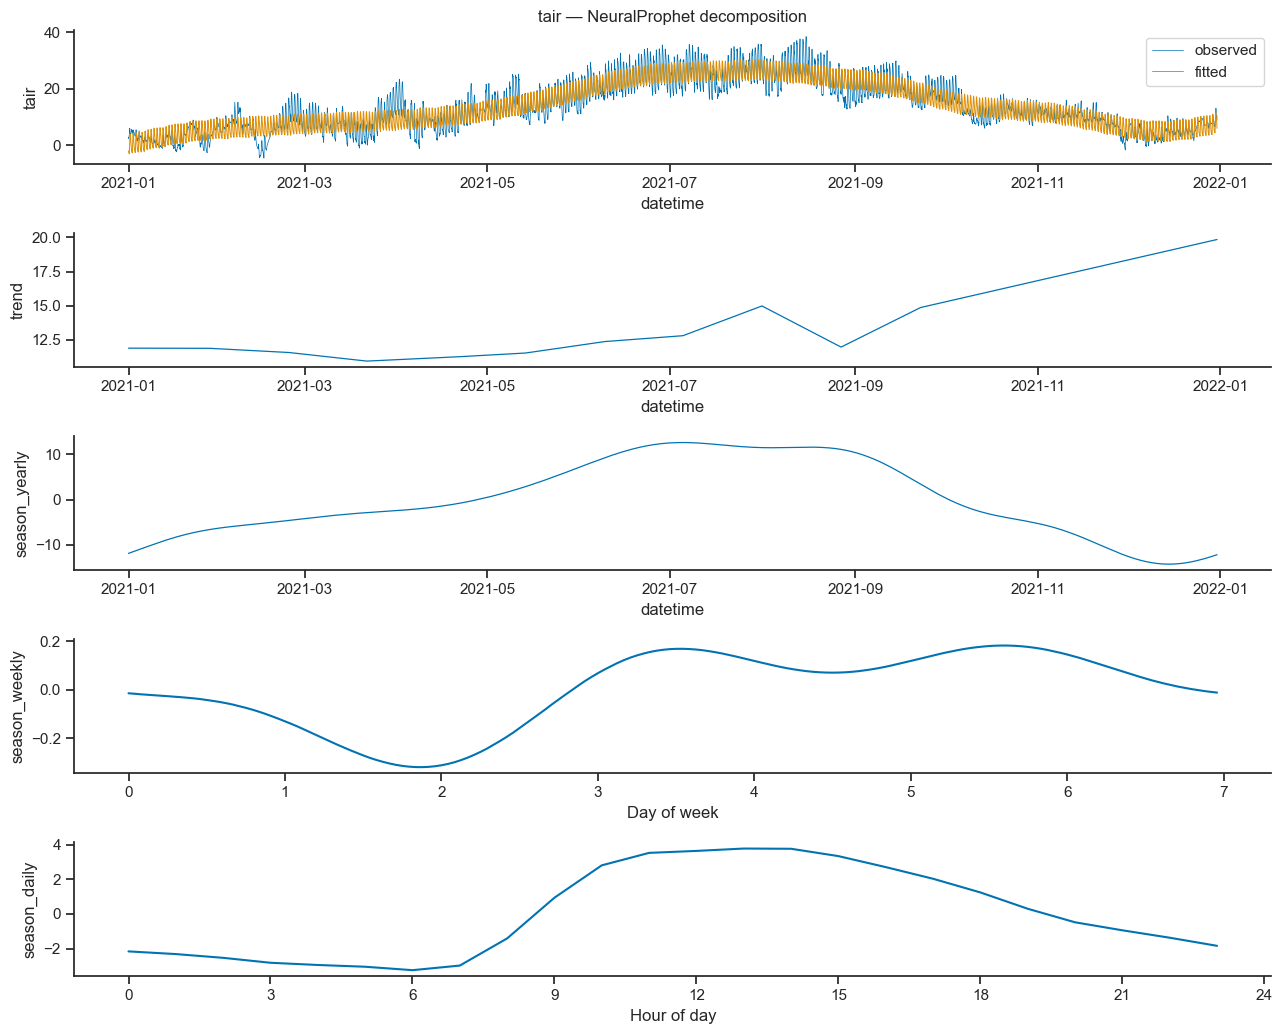

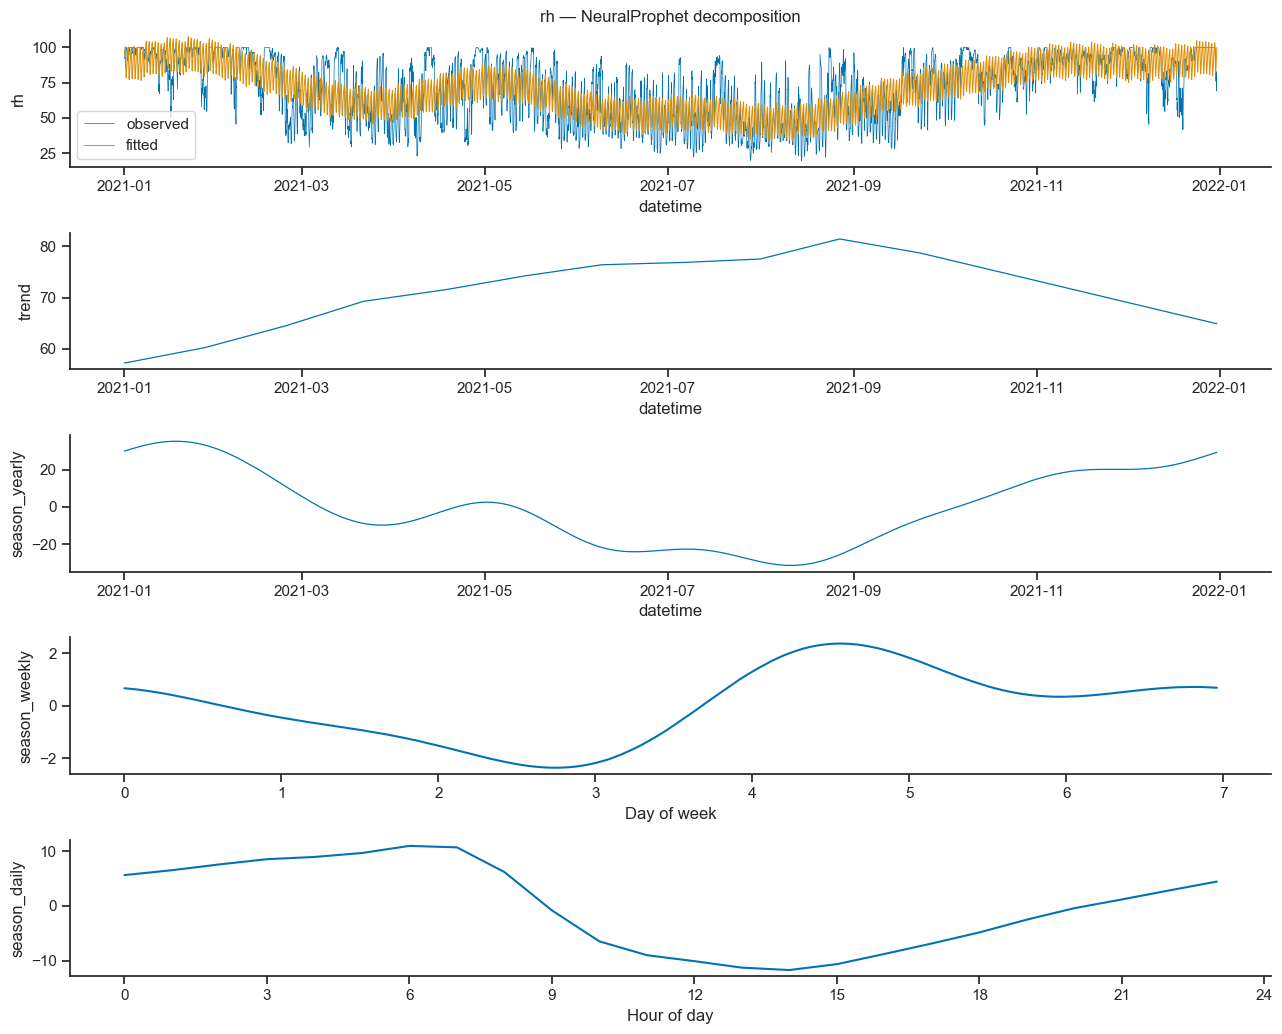

In [11]:
for name in ['inc'] + DRIVERS:
    fig = lc.plot_decomposition(
        decomp[name], name, save_path=OUTPUT_DIR,
        filename=f'S2_06_{STATION}_decomposition_{name}')
    plt.show()

### How much of each series is trend, season, and remainder?

In [12]:
rows = []
for name, comp in decomp.items():
    obs = comp['observed']
    resid = obs - comp['yhat']
    row = {'series': name,
           'var_observed': round(float(obs.var()), 3),
           'var_residual': round(float(resid.var()), 3),
           'explained_%': round(100 * (1 - resid.var() / obs.var()), 1)}
    for c in comp.columns:
        if c == 'trend' or c.startswith('season_'):
            row[f'std_{c}'] = round(float(comp[c].std()), 3)
    rows.append(row)
decomp_summary = pd.DataFrame(rows).set_index('series')
display(decomp_summary)
decomp_summary.to_csv(f'{OUTPUT_DIR}/S2_07_{STATION}_decomposition_summary.csv')

,var_observed,var_residual,explained_%,std_trend,std_season_yearly,std_season_weekly,std_season_daily
series,,,,,,,
inc,1148.583,87.735,92.4,14.035,36.131,0.487,6.438
tair,77.750,10.399,86.6,2.551,8.398,0.155,2.554
rh,488.902,208.520,57.3,6.318,20.124,1.358,7.756


## Step 4 · Imputation of the regressors

Only the regressors are filled, and only with their own trend-plus-seasonal fit. The
inclinometer is left with its gaps: imputing the target and then scoring a forecast
against the imputed values would measure the imputation model, not the forecast.

In [13]:
if IMPUTE_REGRESSORS:
    imputed_masks = {}
    for name in DRIVERS:
        filled, mask = lc.impute_series(df[name], components=decomp[name])
        df[name + '_observed'] = df[name]
        df[name] = filled
        imputed_masks[name] = mask
        print(f'{name}: filled {int(mask.sum())} of {len(mask)} slots '
              f'({100 * mask.mean():.1f} %)')
else:
    imputed_masks = {}
    print('Regressor imputation disabled.')

tair: filled 221 of 8737 slots (2.5 %)
rh: filled 221 of 8737 slots (2.5 %)


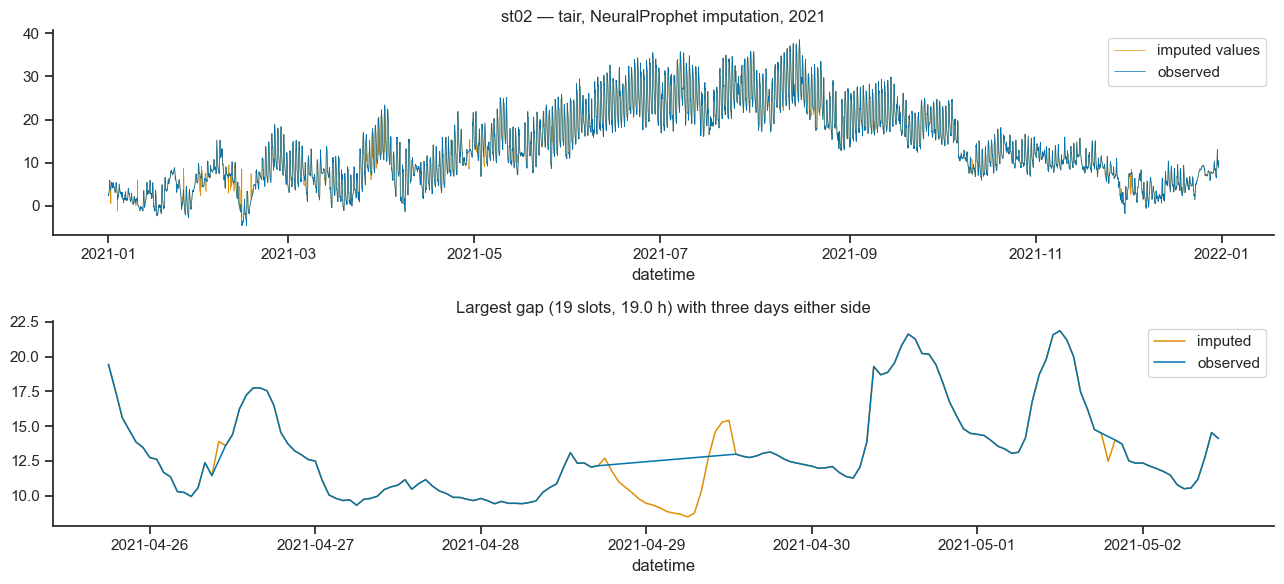

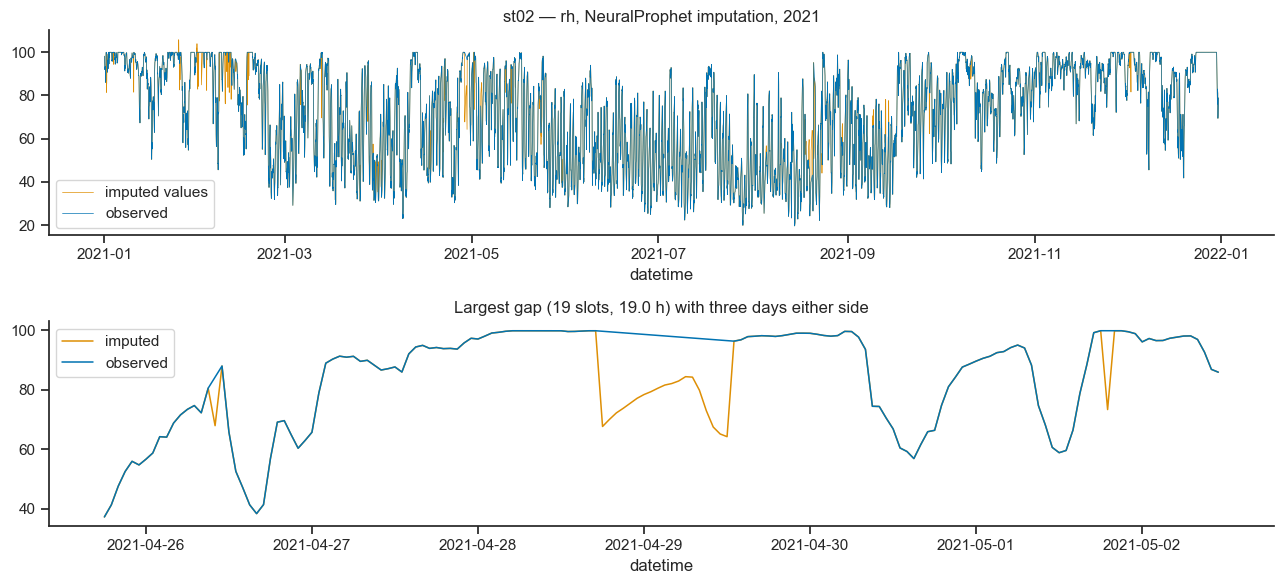

In [14]:
for name in DRIVERS:
    if name in imputed_masks and imputed_masks[name].any():
        fig = lc.plot_imputation(
            df[name + '_observed'], df[name], imputed_masks[name],
            title=f'{STATION} — {name}, NeuralProphet imputation, {YEAR}',
            save_path=OUTPUT_DIR,
            filename=f'S2_08_{STATION}_imputation_{name}')
        plt.show()

## Step 5 · Correlation and lag structure

Only two candidate drivers exist in this era. Both matrices are shown: levels
correlations between trending series are inflated by the shared trend, differenced
correlations describe the relationship at the sampling scale.

In [15]:
cols = ['inc'] + DRIVERS
lev = lc.correlation_matrix(df, cols, differenced=False)
dif = lc.correlation_matrix(df, cols, differenced=True)
print('Pearson, levels:');            display(lev.round(3))
print('Pearson, first differences:'); display(dif.round(3))
lev.to_csv(f'{OUTPUT_DIR}/S2_09_{STATION}_corr_levels.csv')
dif.to_csv(f'{OUTPUT_DIR}/S2_10_{STATION}_corr_differenced.csv')

Pearson, levels:


,inc,tair,rh
inc,1.000,0.238,-0.405
tair,0.238,1.000,-0.692
rh,-0.405,-0.692,1.000


Pearson, first differences:


,inc,tair,rh
inc,1.000,0.866,-0.696
tair,0.866,1.000,-0.706
rh,-0.696,-0.706,1.000


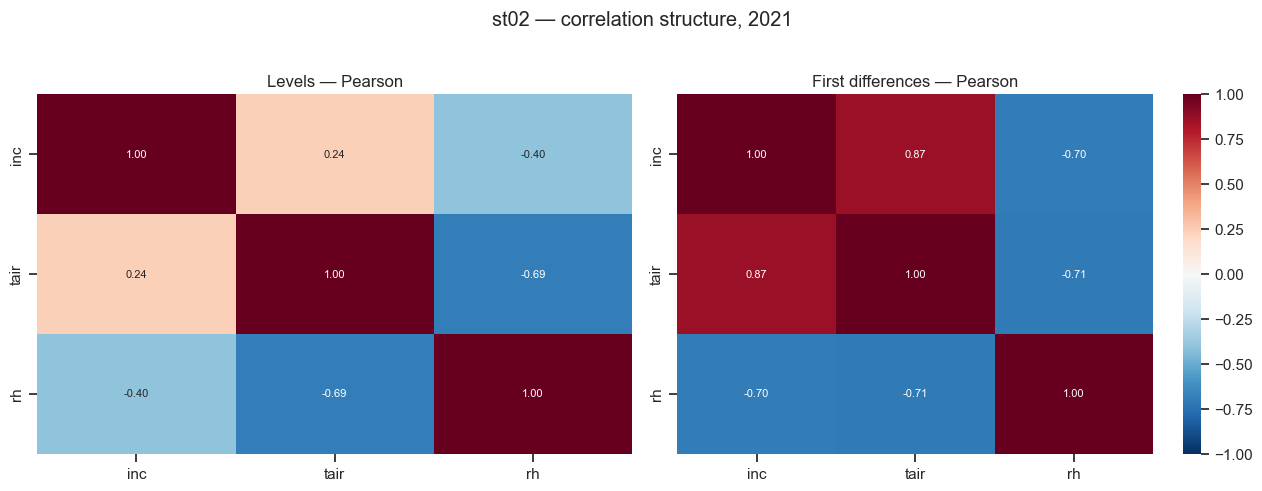

In [16]:
fig = lc.plot_correlation_heatmaps(
    df, cols, title=f'{STATION} — correlation structure, {YEAR}',
    save_path=OUTPUT_DIR, filename=f'S2_11_{STATION}_corr_heatmaps')
plt.show()

### Lag structure, measured twice

Cross-correlation over ±5 days, on levels as well as on first differences. The two
disagree systematically over a full year and the disagreement is the point:
differencing is a high-pass filter, so the differenced panel sees only how the signal
tracks the driver from hour to hour, while the levels panel retains the slow
component in which the thermal mass of the wall expresses itself.

In [17]:
ccf_dif = lc.cross_correlation(df, 'inc', DRIVERS, MAX_LAG_STEPS,
                               differenced=True)
ccf_lev = lc.cross_correlation(df, 'inc', DRIVERS, MAX_LAG_STEPS,
                               differenced=False)
peaks_dif = lc.peak_lags(ccf_dif, SAMPLING_HOURS)
peaks_lev = lc.peak_lags(ccf_lev, SAMPLING_HOURS,
                         match_sign=True, positive_only=True)
print('First differences:'); display(peaks_dif)
print('Levels:');            display(peaks_lev)
peaks_dif.to_csv(f'{OUTPUT_DIR}/S2_12_{STATION}_peak_lags.csv')
peaks_lev.to_csv(f'{OUTPUT_DIR}/S2_31_{STATION}_peak_lags_levels.csv')

First differences:


,peak_corr,peak_lag_steps,peak_lag_hours,corr_at_lag0
driver,,,,
tair,0.8657,0,0.0,0.8657
rh,-0.6960,0,0.0,-0.6960


Levels:


,peak_corr,peak_lag_steps,peak_lag_hours,corr_at_lag0
driver,,,,
tair,0.2378,0,0.0,0.2378
rh,-0.4045,0,0.0,-0.4045


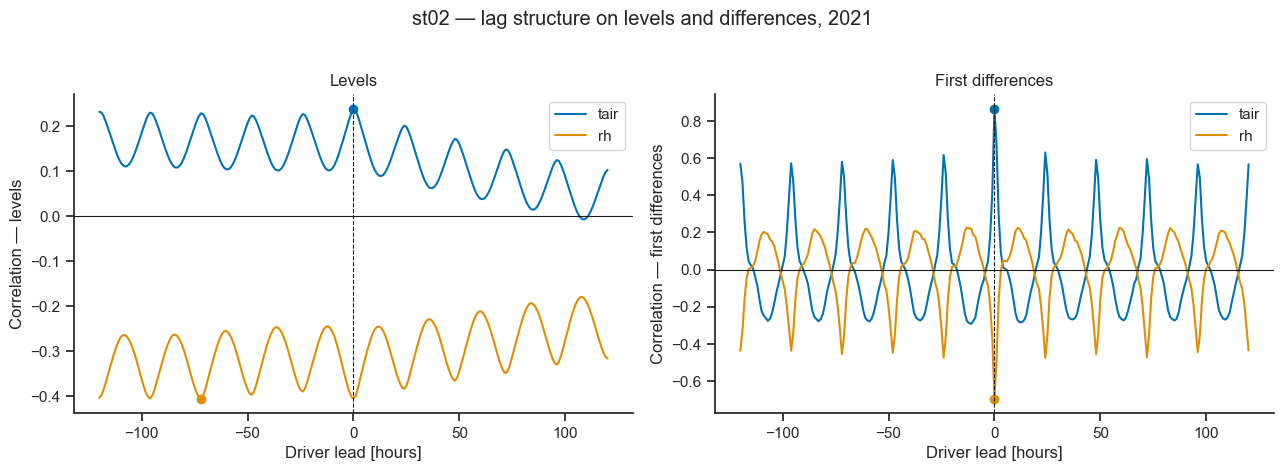

In [18]:
fig = lc.plot_lag_scan(
    ccf_lev, ccf_dif, SAMPLING_HOURS,
    title=f'{STATION} — lag structure on levels and differences, {YEAR}',
    save_path=OUTPUT_DIR, filename=f'S2_13_{STATION}_cross_correlation')
plt.show()

### Seasonal-scale lag

The scan above reaches five days, which is the right range for a daily response and
far too short for an annual one. Two estimators are used at the seasonal scale, and
both are constructed to be immune to a trap that catches the obvious approach: the
cross-correlation of two near-annual cycles is itself near-annual, so the largest
*absolute* correlation sits about half a year away, where the two are simply in
anti-phase. That is a property of periodicity, not a lag.

The first estimator therefore scans daily means over ±150 days but keeps only lags
whose correlation has the sign of the contemporaneous one. The second sidesteps
correlation entirely and simply reports the day of the year on which a 30-day
centred mean of each series reaches its maximum. Deliberately, it does not use the
decomposition: the split between a piecewise-linear trend and a Fourier annual term
is not unique, and at this resolution the fit puts much of the annual cycle into the
trend, which makes the phase of the fitted `season_yearly` component meaningless as
a physical quantity. A rolling mean assumes nothing.

If the inclination turns out to *lead* air temperature, no thermal lag can reproduce
the relationship, because a causal filter can only delay a driver and never advance
it.

In [19]:
daily = df[['inc'] + DRIVERS].resample('1D').mean()
ccf_season = lc.cross_correlation(daily, 'inc', DRIVERS, 150, differenced=False)
peaks_season = lc.peak_lags(ccf_season, 24.0, match_sign=True)
display(peaks_season)
peaks_season.to_csv(f'{OUTPUT_DIR}/S2_39_{STATION}_peak_lags_seasonal.csv')

,peak_corr,peak_lag_steps,peak_lag_hours,corr_at_lag0
driver,,,,
tair,0.7982,-89,-2136.0,0.1636
rh,-0.7097,-58,-1392.0,-0.3672


In [20]:
smooth = daily.rolling(30, center=True, min_periods=20).mean()
rows = []
for name in ['inc'] + DRIVERS:
    s = smooth[name].dropna()
    rows.append({'series': name,
                 'peak_date': s.idxmax().date().isoformat(),
                 'peak_day_of_year': int(s.idxmax().dayofyear),
                 'trough_day_of_year': int(s.idxmin().dayofyear),
                 'seasonal_range': round(float(s.max() - s.min()), 3)})
season_phase = pd.DataFrame(rows).set_index('series')
ref = season_phase.loc[TEMP_COL, 'peak_day_of_year']
season_phase['lead_over_tair_days'] = ref - season_phase['peak_day_of_year']
display(season_phase)
season_phase.to_csv(f'{OUTPUT_DIR}/S2_41_{STATION}_seasonal_phase.csv')

,peak_date,peak_day_of_year,trough_day_of_year,seasonal_range,lead_over_tair_days
series,,,,,
inc,2021-06-07,158,294,90.032,59
tair,2021-08-05,217,6,24.789,0
rh,2021-01-11,11,220,47.587,206


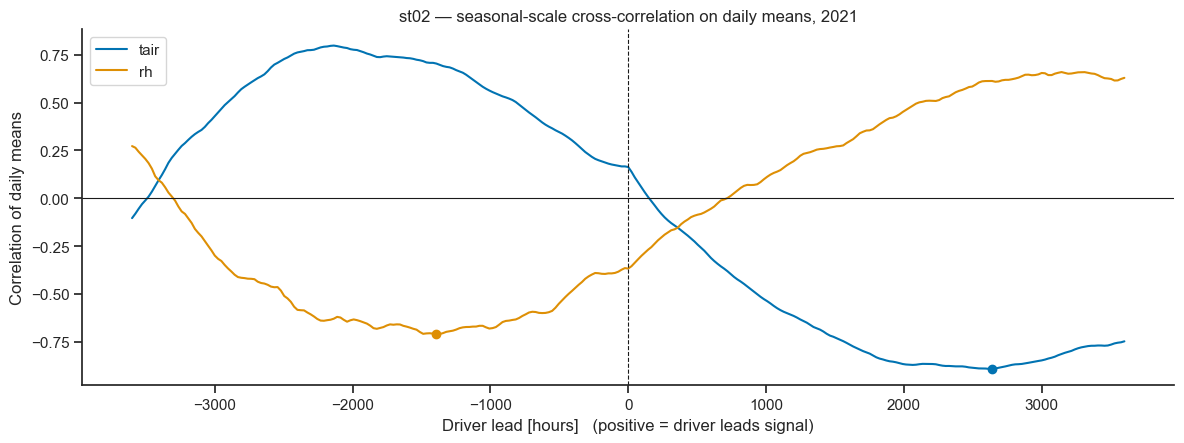

In [21]:
fig = lc.plot_cross_correlation(
    ccf_season, 24.0,
    title=f'{STATION} — seasonal-scale cross-correlation on daily means, {YEAR}',
    save_path=OUTPUT_DIR, filename=f'S2_40_{STATION}_cross_correlation_seasonal',
    ylabel='Correlation of daily means')
plt.show()

### Thermal inertia

A shift assumes the structure reproduces the driver exactly, only later. A wall
integrates instead, so its effective temperature is a smoothed and delayed version of
the forcing. The standard first-order model of that is a single-pole low-pass filter
with time constant $\tau$, and scanning $\tau$ asks the physical question directly.
$\tau = 0$ is the instantaneous assumption, so the correction's premise is included
in the scan rather than argued about separately.

The scan is run twice: on the full signal, and on the residual from a centred weekly
mean. Over a calendar year the first is dominated by the annual cycle and the second
isolates the daily response. If they disagree, no single instantaneous coefficient can
serve both.

In [22]:
scan = lc.inertia_scan(df, 'inc', DRIVERS, TAUS)
best_tau = lc.best_inertia(scan)
print('Full signal:'); display(best_tau)
scan.to_csv(f'{OUTPUT_DIR}/S2_32_{STATION}_inertia_scan.csv', index=False)
best_tau.to_csv(f'{OUTPUT_DIR}/S2_33_{STATION}_best_inertia.csv')

Full signal:


,best_tau_hours,slope_at_best,r2_at_best,r2_instantaneous,r2_gain
driver,,,,,
tair,0.0,0.9139,0.0565,0.0565,0.0
rh,0.0,-0.6201,0.1637,0.1637,0.0


In [23]:
scan_band = lc.inertia_scan(df, 'inc', DRIVERS, TAUS,
                            detrend_hours=BAND_HOURS)
best_tau_band = lc.best_inertia(scan_band)
print('Diurnal band (weekly mean removed):'); display(best_tau_band)
scan_band.to_csv(f'{OUTPUT_DIR}/S2_34_{STATION}_inertia_scan_band.csv',
                 index=False)
best_tau_band.to_csv(f'{OUTPUT_DIR}/S2_35_{STATION}_best_inertia_band.csv')

Diurnal band (weekly mean removed):


,best_tau_hours,slope_at_best,r2_at_best,r2_instantaneous,r2_gain
driver,,,,,
tair,0.0,2.3328,0.9152,0.9152,0.0
rh,0.0,-0.3599,0.3780,0.3780,0.0


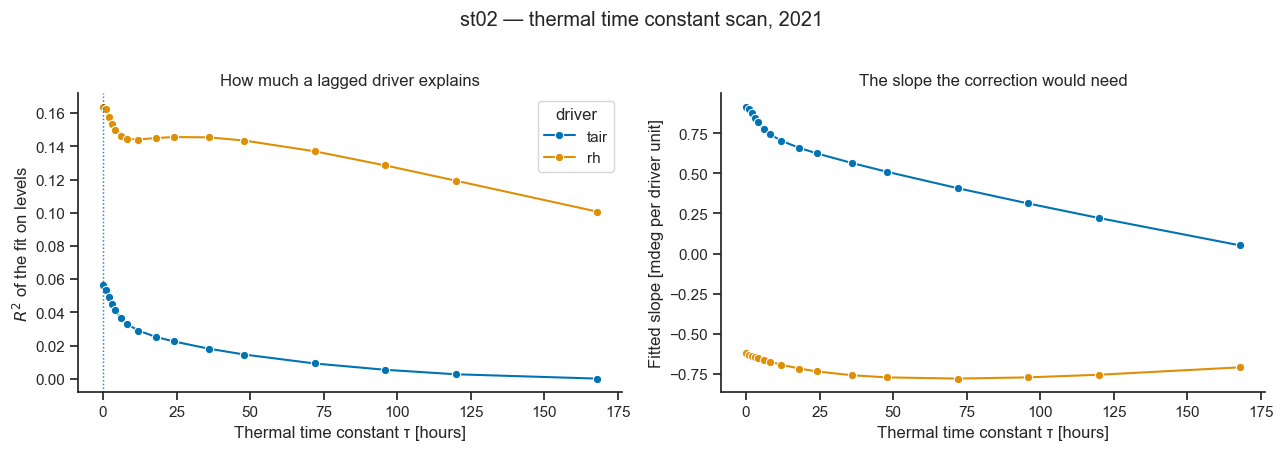

In [24]:
fig = lc.plot_inertia_scan(
    scan, title=f'{STATION} — thermal time constant scan, {YEAR}',
    save_path=OUTPUT_DIR, filename=f'S2_36_{STATION}_inertia_scan')
plt.show()

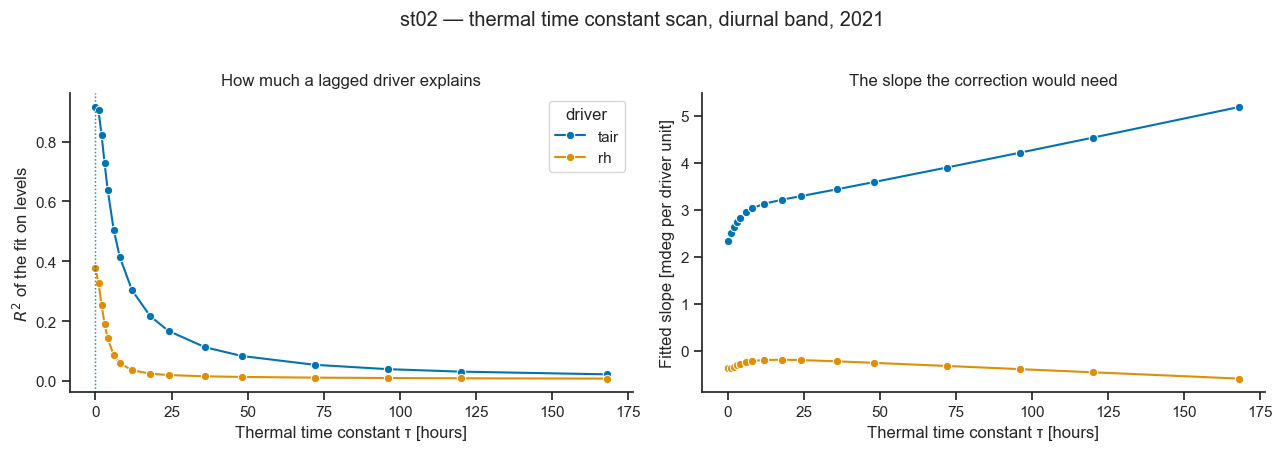

In [25]:
fig = lc.plot_inertia_scan(
    scan_band,
    title=f'{STATION} — thermal time constant scan, diurnal band, {YEAR}',
    save_path=OUTPUT_DIR, filename=f'S2_37_{STATION}_inertia_scan_band')
plt.show()

## Step 6 · How large is the thermal response over a full year?

A full year covers the entire temperature range the structure experiences, so this
is the best-conditioned estimate of the thermal slope available anywhere in the
archive. The comparison value is **5.0 mdeg/°C**, the slope the documented
coefficient implies.

In [26]:
slopes_lev = lc.slope_table(df, 'inc', DRIVERS, differenced=False)
slopes_dif = lc.slope_table(df, 'inc', DRIVERS, differenced=True)
print(f'Documented coefficient implies {lc.DOCUMENTED_COEFF * 1000:.1f} mdeg per °C\n')
print('Levels:');            display(slopes_lev)
print('First differences:'); display(slopes_dif)
slopes_lev.to_csv(f'{OUTPUT_DIR}/S2_14_{STATION}_slopes_levels.csv')
slopes_dif.to_csv(f'{OUTPUT_DIR}/S2_15_{STATION}_slopes_differenced.csv')

Documented coefficient implies 5.0 mdeg per °C

Levels:


,slope,ci_low,ci_high,se,r2,n
driver,,,,,,
tair,0.9139,0.6287,1.1991,0.1455,0.0565,8516
rh,-0.6201,-0.7355,-0.5046,0.0589,0.1637,8516


First differences:


,slope,ci_low,ci_high,se,r2,n
driver,,,,,,
tair,2.2603,2.1804,2.3402,0.0408,0.7495,8432
rh,-0.4729,-0.5003,-0.4455,0.0140,0.4844,8432


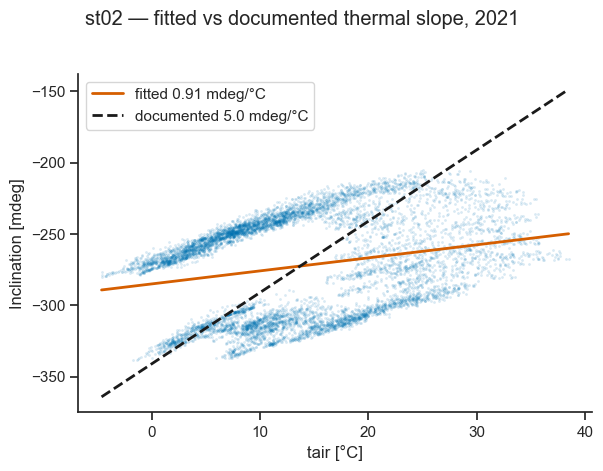

In [27]:
fig = lc.plot_thermal_scatter(
    df, temp_cols=('tair',),
    title=f'{STATION} — fitted vs documented thermal slope, {YEAR}',
    save_path=OUTPUT_DIR, filename=f'S2_16_{STATION}_thermal_scatter')
plt.show()

In [28]:
mv = lc.multivariate_fit(df, 'inc', DRIVERS)
print(mv.summary().tables[1])
print(f'\nR-squared: {mv.rsquared:.4f}   n = {int(mv.nobs)}')

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -217.7808      7.091    -30.712      0.000    -231.679    -203.882
tair          -0.3013      0.186     -1.624      0.104      -0.665       0.062
rh            -0.7029      0.075     -9.399      0.000      -0.849      -0.556

R-squared: 0.1669   n = 8516


## Step 7 · Acceptance tests for the compensation

The correction claims to remove the thermal component. Three falsifiable
consequences: variance should fall, correlation with temperature should move towards
zero, and the daily swing should shrink.

In [29]:
term   = lc.compensation_term(df, temp_col=TEMP_COL, coeff=lc.DOCUMENTED_COEFF)
unnorm = df['inc'] - term
shift  = unnorm.dropna().iloc[0]

df['comp_term']  = term
df['comp_shift'] = shift
df['inc_comp']   = unnorm - shift

recon = df['inc_comp'] + df['comp_term'] + df['comp_shift']
assert np.nanmax(np.abs(recon - df['inc'])) < 1e-9, 'compensation is not invertible'
print('Compensation is exactly invertible — raw-scale scoring is valid.')

Compensation is exactly invertible — raw-scale scoring is valid.


In [30]:
tests = lc.compensation_tests(df, df['inc_comp'],
                              temp_cols=('tair',), extra_drivers=('rh',))
display(tests)
tests.to_csv(f'{OUTPUT_DIR}/S2_17_{STATION}_acceptance_tests.csv')

,raw,compensated,target,change_%,verdict
test,,,,,
variance [mdeg^2],1148.5830,2381.7560,lower,107.4,WORSE
std [mdeg],33.8910,48.8030,lower,44.0,WORSE
mean diurnal amplitude [mdeg],21.0390,23.9200,lower,13.7,WORSE
|corr| with tair (levels),0.2378,0.7383,lower,210.5,WORSE
|corr| with tair (differenced),0.8657,0.9026,lower,4.3,WORSE
|corr| with rh (levels),0.4045,0.3419,lower,-15.5,improved
|corr| with rh (differenced),0.6960,0.6972,lower,0.2,WORSE


In [31]:
signs = lc.signed_correlation_check(df, df['inc_comp'], cols=('tair', 'rh'))
display(signs)
signs.to_csv(f'{OUTPUT_DIR}/S2_18_{STATION}_signed_correlations.csv')

,corr_raw,corr_compensated,sign_flipped,overcorrected
driver,,,,
tair,0.2378,-0.7383,True,True
rh,-0.4045,0.3419,True,True


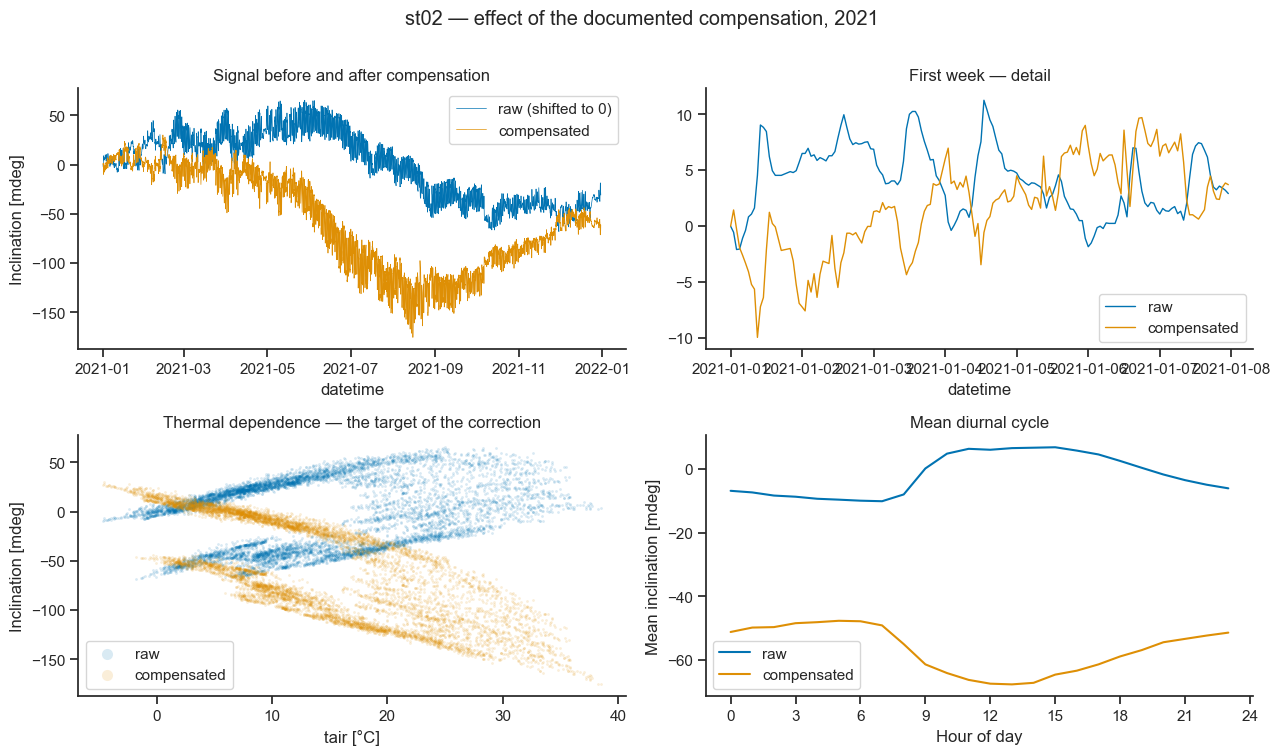

In [32]:
fig = lc.plot_compensation_effect(
    df, df['inc_comp'], temp_col=TEMP_COL,
    title=f'{STATION} — effect of the documented compensation, {YEAR}',
    save_path=OUTPUT_DIR, filename=f'S2_19_{STATION}_compensation_effect')
plt.show()

## Step 8 · Where does the documented coefficient sit over a full year?

In [33]:
sweep = lc.coefficient_sweep(df, temp_col=TEMP_COL)
best  = sweep.loc[sweep['residual_var'].idxmin()]
zero  = sweep.loc[(sweep['coeff'] - 0).abs().idxmin()]
docv  = sweep.loc[(sweep['coeff'] - lc.DOCUMENTED_COEFF).abs().idxmin()]

print(f"variance-minimising : {best['mdeg_per_degC']:7.3f} mdeg/°C  "
      f"residual var {best['residual_var']:9.2f}  |r| {best['abs_corr_with_temp']:.3f}")
print(f"no compensation     : {zero['mdeg_per_degC']:7.3f} mdeg/°C  "
      f"residual var {zero['residual_var']:9.2f}  |r| {zero['abs_corr_with_temp']:.3f}")
print(f"documented          : {docv['mdeg_per_degC']:7.3f} mdeg/°C  "
      f"residual var {docv['residual_var']:9.2f}  |r| {docv['abs_corr_with_temp']:.3f}")
sweep.to_csv(f'{OUTPUT_DIR}/S2_20_{STATION}_coefficient_sweep.csv', index=False)

variance-minimising :   1.000 mdeg/°C  residual var   1084.22  |r| 0.023
no compensation     :   0.000 mdeg/°C  residual var   1148.58  |r| 0.238
documented          :   5.000 mdeg/°C  residual var   2381.76  |r| 0.738


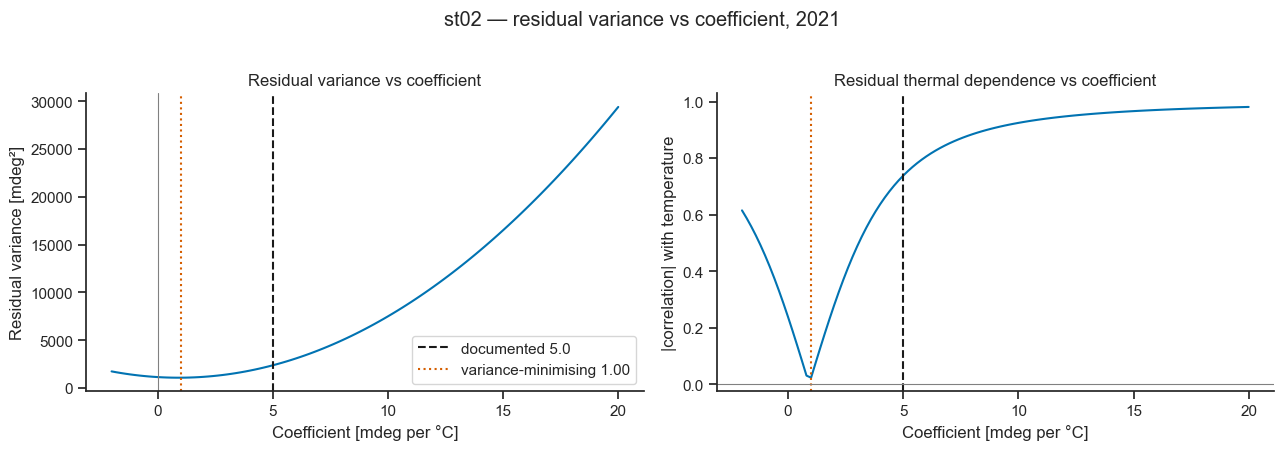

In [34]:
fig = lc.plot_coefficient_sweep(
    sweep, title=f'{STATION} — residual variance vs coefficient, {YEAR}',
    save_path=OUTPUT_DIR, filename=f'S2_21_{STATION}_coefficient_sweep')
plt.show()

## Step 9 · The prediction experiment

The same four configurations as the current-era study, with the regressor set
reduced to what this era provides. Every configuration is scored **on the raw signal
scale**: predictions of a compensated target have the correction added back first,
so all four predict the same physical quantity.

The controlled contrast is again **C against D** — identical model form, differing
only in whether the target was compensated.

Two further configurations test the physics rather than the correction. E supplies
each driver shifted to the lag that maximised its cross-correlation on levels; F
supplies each driver filtered through the time constant that won the band-limited
scan, which is the fast response the forecasting model's own trend and seasonal terms
do not already carry. Both act on the raw target, so they compete with A and D.

In [35]:
lag_spec = {c: int(round(peaks_lev.loc[c, 'peak_lag_hours'] / SAMPLING_HOURS))
            for c in DRIVERS}
tau_spec = {c: float(best_tau_band.loc[c, 'best_tau_hours']) for c in DRIVERS}
print('lags  [steps]:', lag_spec)
print('taus  [hours]:', tau_spec)

lc.add_lagged(df, lag_spec)
lc.add_inertia(df, tau_spec)
LAGGED   = [f'{c}_lag{lag_spec[c]}' for c in DRIVERS]
INERTIAL = [f'{c}_tau{int(round(tau_spec[c]))}' for c in DRIVERS]

lags  [steps]: {'tair': 0, 'rh': 0}
taus  [hours]: {'tair': 0.0, 'rh': 0.0}


In [36]:
CONFIGS = {
    'A · raw + thermal regressors': {
        'target': 'inc', 'regressors': DRIVERS, 'add_back': False},
    'B · compensated + thermal regressors': {
        'target': 'inc_comp', 'regressors': DRIVERS, 'add_back': True},
    'C · compensated, no thermal regressors': {
        'target': 'inc_comp', 'regressors': [], 'add_back': True},
    'D · raw, no thermal regressors': {
        'target': 'inc', 'regressors': [], 'add_back': False},
    'E · raw + lag-optimised regressors': {
        'target': 'inc', 'regressors': LAGGED, 'add_back': False},
    'F · raw + thermal-inertia regressors': {
        'target': 'inc', 'regressors': INERTIAL, 'add_back': False},
}

In [37]:
res_1, preds_1 = lc.run_ridge_experiment(
    df, CONFIGS, n_lags=N_LAGS_MODEL, horizon=1, train_frac=TRAIN_FRAC)
display(res_1)
res_1.to_csv(f'{OUTPUT_DIR}/S2_22_{STATION}_ridge_h1.csv')

,target,regressors,n_train,n_test,MAE_mdeg,RMSE_mdeg,MAE_vs_best_%
config,,,,,,,
A · raw + thermal regressors,inc,"tair, rh",5436,2330,0.9878,1.5088,0.00
B · compensated + thermal regressors,inc_comp,"tair, rh",5436,2330,2.0760,2.6780,110.16
"C · compensated, no thermal regressors",inc_comp,none,5436,2330,1.5443,2.2041,56.34
"D · raw, no thermal regressors",inc,none,5436,2330,1.0480,1.5494,6.09
E · raw + lag-optimised regressors,inc,"tair_lag0, rh_lag0",5436,2330,0.9878,1.5088,0.00
F · raw + thermal-inertia regressors,inc,"tair_tau0, rh_tau0",5436,2330,0.9878,1.5088,0.00


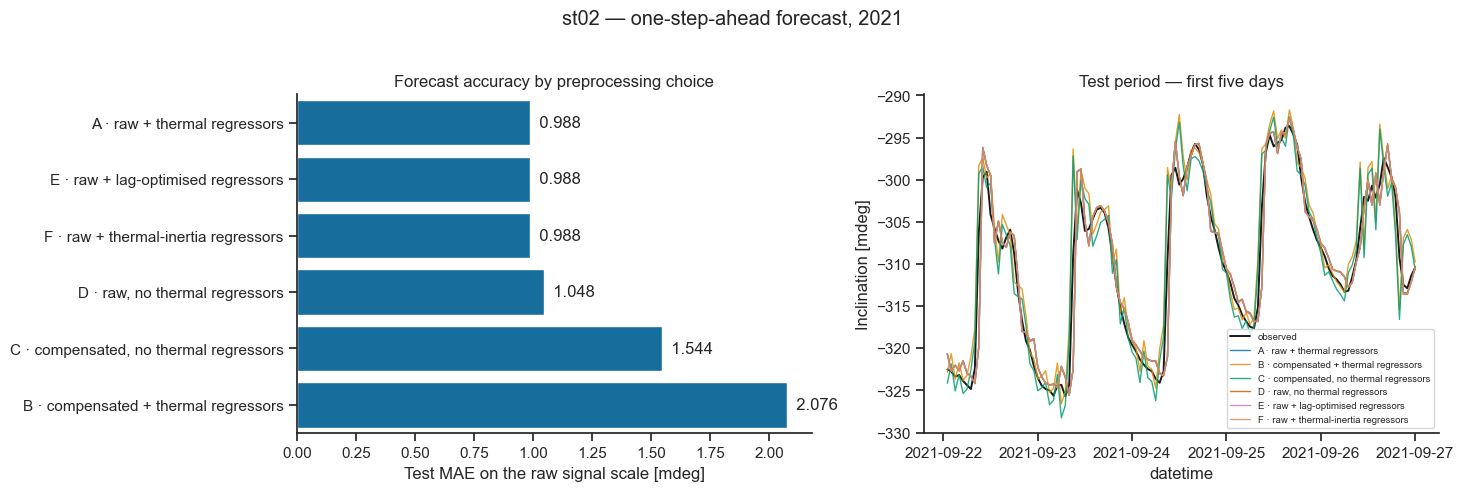

In [38]:
fig = lc.plot_experiment(
    res_1, preds_1, df['inc'],
    title=f'{STATION} — one-step-ahead forecast, {YEAR}',
    save_path=OUTPUT_DIR, filename=f'S2_23_{STATION}_experiment_h1')
plt.show()

In [39]:
res_24, preds_24 = lc.run_ridge_experiment(
    df, CONFIGS, n_lags=N_LAGS_MODEL, horizon=HORIZON_LONG, train_frac=TRAIN_FRAC)
display(res_24)
res_24.to_csv(f'{OUTPUT_DIR}/S2_24_{STATION}_ridge_h24.csv')

,target,regressors,n_train,n_test,MAE_mdeg,RMSE_mdeg,MAE_vs_best_%
config,,,,,,,
A · raw + thermal regressors,inc,"tair, rh",5350,2294,3.9242,5.1083,0.00
B · compensated + thermal regressors,inc_comp,"tair, rh",5350,2294,7.9082,8.8802,101.52
"C · compensated, no thermal regressors",inc_comp,none,5350,2294,4.0692,5.2063,3.70
"D · raw, no thermal regressors",inc,none,5350,2294,4.0404,5.2348,2.96
E · raw + lag-optimised regressors,inc,"tair_lag0, rh_lag0",5350,2294,3.9242,5.1083,0.00
F · raw + thermal-inertia regressors,inc,"tair_tau0, rh_tau0",5350,2294,3.9242,5.1083,0.00


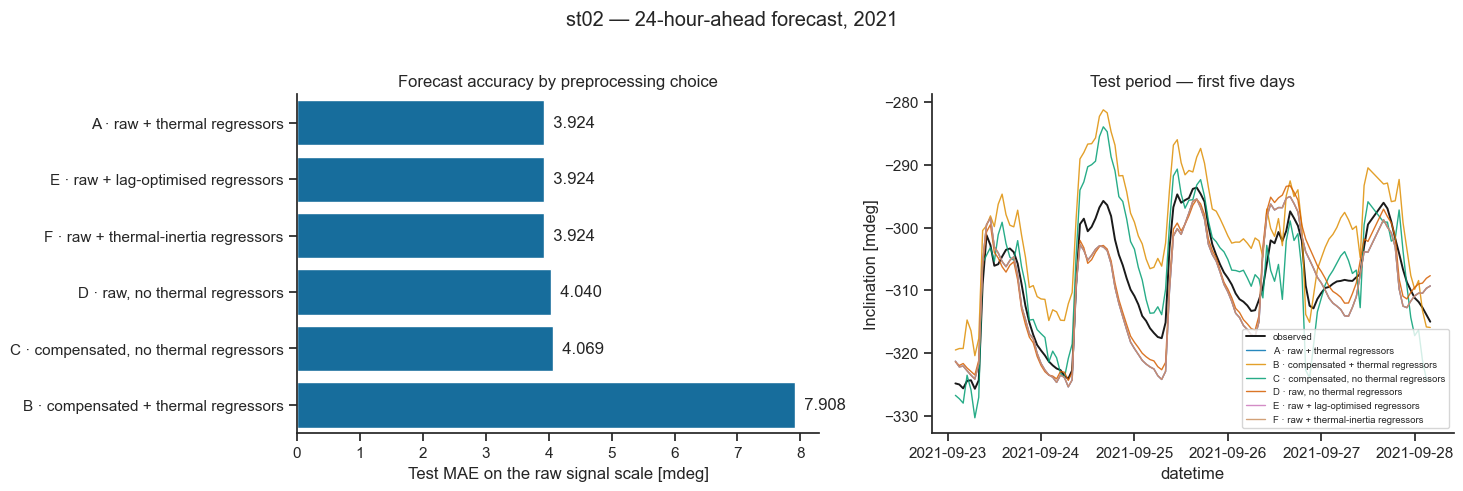

In [40]:
fig = lc.plot_experiment(
    res_24, preds_24, df['inc'],
    title=f'{STATION} — 24-hour-ahead forecast, {YEAR}',
    save_path=OUTPUT_DIR, filename=f'S2_25_{STATION}_experiment_h24')
plt.show()

### The controlled contrast

In [41]:
KEY_A = 'A · raw + thermal regressors'
KEY_C = 'C · compensated, no thermal regressors'
KEY_D = 'D · raw, no thermal regressors'

rows = []
for label, t in [('1 h', res_1), ('24 h', res_24)]:
    rows.append({
        'year': YEAR, 'horizon': label,
        'MAE raw (D)': t.loc[KEY_D, 'MAE_mdeg'],
        'MAE compensated (C)': t.loc[KEY_C, 'MAE_mdeg'],
        'compensation penalty %': round(
            100 * (t.loc[KEY_C, 'MAE_mdeg'] - t.loc[KEY_D, 'MAE_mdeg'])
            / t.loc[KEY_D, 'MAE_mdeg'], 1),
        'MAE raw+regressors (A)': t.loc[KEY_A, 'MAE_mdeg'],
    })
contrast_table = pd.DataFrame(rows)
display(contrast_table)
contrast_table.to_csv(f'{OUTPUT_DIR}/S2_26_{STATION}_controlled_contrast.csv',
                      index=False)

,year,horizon,MAE raw (D),MAE compensated (C),compensation penalty %,MAE raw+regressors (A)
0,2021,1 h,1.0480,1.5443,47.4,0.9878
1,2021,24 h,4.0404,4.0692,0.7,3.9242


## Step 10 · Confirmation under NeuralProphet

Unlike the current-era study, this one covers a full calendar year, so the annual
term is switched on here.

The autoregressive window needs continuous history, so gaps in the input are bridged
by interpolation — but the error is computed **only at timestamps that were actually
observed**. The model may read a filled value; it is never scored against one. That
distinction is what keeps the comparison honest, and it is applied identically to
all four configurations.

In [42]:
if RUN_NEURALPROPHET:
    res_np = lc.run_neuralprophet_experiment(
        df, CONFIGS, freq=ANALYSIS_FREQ, train_frac=TRAIN_FRAC,
        n_lags=NP_LAGS, epochs=NP_EPOCHS, horizon=1,
        yearly_seasonality=True)
    display(res_np)
    res_np.to_csv(f'{OUTPUT_DIR}/S2_27_{STATION}_neuralprophet_h1.csv')
else:
    res_np = None
    print('NeuralProphet confirmation skipped.')

,target,regressors,n_test,MAE_mdeg,RMSE_mdeg,MAE_vs_best_%
config,,,,,,
A · raw + thermal regressors,inc,"tair, rh",2600,2.7765,3.5824,0.00
B · compensated + thermal regressors,inc_comp,"tair, rh",2600,3.4718,4.3762,25.04
"C · compensated, no thermal regressors",inc_comp,none,2600,3.2906,4.0972,18.52
"D · raw, no thermal regressors",inc,none,2600,3.0151,3.7775,8.59
E · raw + lag-optimised regressors,inc,"tair_lag0, rh_lag0",2600,2.7765,3.5824,0.00
F · raw + thermal-inertia regressors,inc,"tair_tau0, rh_tau0",2600,2.7765,3.5824,0.00


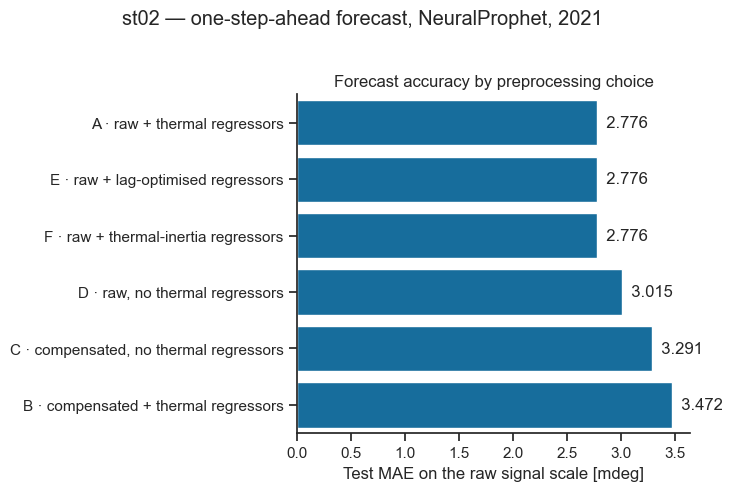

In [43]:
if res_np is not None and len(res_np):
    fig = lc.plot_experiment(
        res_np, title=f'{STATION} — one-step-ahead forecast, NeuralProphet, {YEAR}',
        save_path=OUTPUT_DIR,
        filename=f'S2_28_{STATION}_experiment_neuralprophet')
    plt.show()

## Step 11 · Verdict

In [44]:
lines = []

r_raw = abs(df['inc'].corr(df[TEMP_COL]))
r_cmp = abs(df['inc_comp'].corr(df[TEMP_COL]))
c1 = r_cmp < r_raw
lines.append(f"1. Thermal dependence on {TEMP_COL}: |r| {r_raw:.3f} -> {r_cmp:.3f}  "
             f"[{'REDUCED' if c1 else 'NOT REDUCED'}]")

c2 = abs(docv['mdeg_per_degC'] - best['mdeg_per_degC']) <= 1.0
lines.append(f"2. Coefficient: documented {docv['mdeg_per_degC']:.2f} vs "
             f"variance-minimising {best['mdeg_per_degC']:.2f} mdeg/°C  "
             f"[{'CLOSE' if c2 else 'FAR'}]")

c3 = bool((contrast_table['compensation penalty %'] <= 0).all())
lo = contrast_table['compensation penalty %'].min()
hi = contrast_table['compensation penalty %'].max()
lines.append(f"3. Forecast, compensated (C) vs raw (D), same model form: "
             f"penalty {lo:+.1f} % to {hi:+.1f} %  "
             f"[{'COMPENSATION HELPS' if c3 else 'COMPENSATION HURTS'}]")

print('\n'.join(lines))
print()
print('Overall:', 'KEEP the compensation' if (c1 and c2 and c3)
      else 'DROP the fixed compensation and let the model estimate the '
           'thermal response')

1. Thermal dependence on tair: |r| 0.238 -> 0.738  [NOT REDUCED]
2. Coefficient: documented 5.00 vs variance-minimising 1.00 mdeg/°C  [FAR]
3. Forecast, compensated (C) vs raw (D), same model form: penalty +0.7 % to +47.4 %  [COMPENSATION HURTS]

Overall: DROP the fixed compensation and let the model estimate the thermal response


In [45]:
summary = pd.DataFrame({
    'criterion': ['thermal dependence reduced',
                  'coefficient near variance-minimising',
                  'improves forecast (controlled contrast)'],
    'passed': [bool(c1), bool(c2), bool(c3)],
})
display(summary)
summary.to_csv(f'{OUTPUT_DIR}/S2_29_{STATION}_verdict.csv', index=False)

,criterion,passed
0,thermal dependence reduced,False
1,coefficient near variance-minimising,False
2,improves forecast (controlled contrast),False


## Step 11b · Is the response instantaneous?

A separate question from the verdict above, and the one that decides how the thermal
response should be modelled once the fixed correction is gone. Over a full year this
study can compare the daily and the annual response of the same structure, which the
current-era study cannot.

In [46]:
KEY_E = 'E · raw + lag-optimised regressors'
KEY_F = 'F · raw + thermal-inertia regressors'

for d in DRIVERS:
    print(f"  {d:<5} peak on levels {peaks_lev.loc[d, 'peak_lag_hours']:+6.1f} h "
          f"| full-signal tau {best_tau.loc[d, 'best_tau_hours']:5.1f} h "
          f"(R2 {best_tau.loc[d, 'r2_instantaneous']:.3f} -> "
          f"{best_tau.loc[d, 'r2_at_best']:.3f}) "
          f"| diurnal-band tau {best_tau_band.loc[d, 'best_tau_hours']:5.1f} h "
          f"(R2 {best_tau_band.loc[d, 'r2_instantaneous']:.3f} -> "
          f"{best_tau_band.loc[d, 'r2_at_best']:.3f})")

inst = res_24.loc['A · raw + thermal regressors', 'MAE_mdeg']
for k in (KEY_E, KEY_F):
    if k in res_24.index:
        g = 100 * (inst - res_24.loc[k, 'MAE_mdeg']) / inst
        print(f'  24 h forecast, {k}: {res_24.loc[k, "MAE_mdeg"]:.3f} mdeg '
              f'({g:+.1f} % against the instantaneous regressors)')

  tair  peak on levels   +0.0 h | full-signal tau   0.0 h (R2 0.057 -> 0.057) | diurnal-band tau   0.0 h (R2 0.915 -> 0.915)
  rh    peak on levels   +0.0 h | full-signal tau   0.0 h (R2 0.164 -> 0.164) | diurnal-band tau   0.0 h (R2 0.378 -> 0.378)
  24 h forecast, E · raw + lag-optimised regressors: 3.924 mdeg (+0.0 % against the instantaneous regressors)
  24 h forecast, F · raw + thermal-inertia regressors: 3.924 mdeg (+0.0 % against the instantaneous regressors)


In [47]:
lag_summary = pd.DataFrame({
    'peak_lag_hours_levels': peaks_lev['peak_lag_hours'],
    'peak_lag_hours_differenced': peaks_dif['peak_lag_hours'],
    'tau_full_signal': best_tau['best_tau_hours'],
    'r2_gain_full_signal': best_tau['r2_gain'],
    'tau_diurnal_band': best_tau_band['best_tau_hours'],
    'r2_gain_band': best_tau_band['r2_gain'],
})
display(lag_summary)
lag_summary.to_csv(f'{OUTPUT_DIR}/S2_38_{STATION}_lag_summary.csv')

,peak_lag_hours_levels,peak_lag_hours_differenced,tau_full_signal,r2_gain_full_signal,tau_diurnal_band,r2_gain_band
driver,,,,,,
tair,0.0,0.0,0.0,0.0,0.0,0.0
rh,0.0,0.0,0.0,0.0,0.0,0.0


## Step 12 · Against the current-era study

The two studies use the same tests on different eras and different instruments, so
the comparison below is meaningful. It is loaded from the sibling study's saved
outputs if they are present.

In [48]:
sibling = '../thermal_compensation/outputs'
try:
    cur_slopes = pd.read_csv(f'{sibling}/S1_10_st02_slopes_levels.csv',
                             index_col=0)
    cur_sweep = pd.read_csv(f'{sibling}/S1_16_st02_coefficient_sweep.csv')
    cur_best = cur_sweep.loc[cur_sweep['residual_var'].idxmin()]
    comparison = pd.DataFrame([
        {'quantity': 'fitted tair slope [mdeg/°C]',
         'legacy (this study)': slopes_lev.loc['tair', 'slope'],
         'current era': cur_slopes.loc['tair', 'slope'],
         'documented': lc.DOCUMENTED_COEFF * 1000},
        {'quantity': 'variance-minimising coefficient [mdeg/°C]',
         'legacy (this study)': best['mdeg_per_degC'],
         'current era': cur_best['mdeg_per_degC'],
         'documented': lc.DOCUMENTED_COEFF * 1000},
    ])
    display(comparison)
    comparison.to_csv(f'{OUTPUT_DIR}/S2_30_{STATION}_era_comparison.csv',
                      index=False)
except FileNotFoundError:
    print('Sibling study outputs not found — run studies/thermal_compensation '
          'first to enable the comparison.')

,quantity,legacy (this study),current era,documented
0,fitted tair slope [mdeg/°C],0.9139,1.6279,5.0
1,variance-minimising coefficient [mdeg/°C],1.0000,1.6000,5.0
